# The Reality of Entry-Level Jobs in the Current Job Market

Whether you are a recent graduate or transitioning into a new career, entry-level roles can provide an accessible starting point to gain industry exposure, build practical skills, and explore long-term career opportunities. A common frustration with entry-level postings is that they do not always feel entry-level. A posting may carry an Entry level label, but the description may still ask for years of experience, ownership of complex projects, advanced tools, leadership responsibilities, or other mid-level expectations.

### Goal

For this project, we are looking to answer the following research question:
> Can we identify postings labeled `Entry level` that are written more like mid-level or senior roles?

We are not looking to judge employers. The goal is to help entry-level job seekers find postings that are actually relevant to them. We would build a model that reads job posting text and metadata, predict the seniority level that best matches the posting’s intention, and flags entry-level-labeled postings that appear inconsistent with their original label.

### Success Metrics

We will evaluate the project in two ways:

- **Model performance:** macro F1, class-level precision/recall, and confusion matrix for seniority classification.
- **Job-seeker usefulness:** whether the high-scoring mismatches contain concrete warning signs such as years of experience, senior verbs, leadership phrases, or advanced degree requirements

## 1. Data Loading

```text
data/raw/linkedin_job_postings/
```
The main file is `postings.csv`, which contains job titles, descriptions, salary fields, seniority labels, location, work type, views, applies, and other posting metadata. Supporting files add skills, industries, salaries, benefits, and company information.

In [ ]:
# import the core libraries used throughout the notebook.
# Later in the notebook, we use TensorFlow and Keras, so the environment should use a Python version compatible with TensorFlow.
# python 3.12.13 was used for this notebook.

from pathlib import Path
import pickle
import re
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
# set the project root directory and define paths to the raw data, SQL scripts, and models directories
PROJECT_ROOT = Path.cwd().resolve()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "linkedin_job_postings"
SQL_DIR = PROJECT_ROOT / "sql"
MODELS_DIR = PROJECT_ROOT / "models"

In [3]:
# Before doing analysis, verify that the project contains the raw files we expect.

expected_files = [
    "postings.csv",
    "jobs/job_skills.csv",
    "jobs/job_industries.csv",
    "jobs/salaries.csv",
    "jobs/benefits.csv",
    "mappings/skills.csv",
    "mappings/industries.csv",
    "companies/companies.csv",
    "companies/employee_counts.csv",
]

missing_files = [file for file in expected_files if not (RAW_DATA_DIR / file).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing expected raw files: {missing_files}")

print("All expected raw files are present in the stand-alone project folder.")

All expected raw files are present in the stand-alone project folder.


After reviewing the raw file structures and columns, we chose SQL because the raw files contain relational data that can be efficiently organized, joined, filtered, and queried using structured database tables. Therefore, we used DuckDB SQL file: 

```text
sql/build_final_table.sql
```

The SQL file reads the raw CSVs, joins skills/industries/salaries/benefits/company context, and returns a table with one row per posting.


In [40]:
# Load the job-level analytical table with DuckDB SQL.

sql_path = SQL_DIR / "build_final_table.sql"
raw_data_path = str(RAW_DATA_DIR).replace("'", "''")

sql_template = sql_path.read_text(encoding="utf-8")
build_jobs_sql = sql_template.replace("__RAW_DATA_DIR__", raw_data_path).rstrip().rstrip(";")

with duckdb.connect() as con:
    jobs = con.execute(build_jobs_sql).df()

print(jobs.shape)
jobs.head(3)

(123849, 40)


,job_id,company_id,company_name,title,description,formatted_experience_level,formatted_work_type,work_type,location,remote_status,...,company_state,company_country,employee_count,follower_count,views,applies,sponsored,listed_time,expiry,job_posting_url
0,3885858721,20708,Palantir Technologies,Operations Analyst - US Government,A World-Changing Company\n\nPalantir builds th...,NaN,Full-time,FULL_TIME,"New York, NY",Remote-Not Eligible,...,Colorado,US,4057,308755,13.0,1.0,0,1.712379e+12,1.714971e+12,https://www.linkedin.com/jobs/view/3885858721/...
1,3885859148,76323347,CenterWell Senior Primary Care,"Physician - CenterWell - Matthews, NC",Become a part of our caring community and help...,NaN,Full-time,FULL_TIME,"Charlotte, NC",Remote-Not Eligible,...,Kentucky,US,1091,19630,6.0,NaN,0,1.712378e+12,1.714970e+12,https://www.linkedin.com/jobs/view/3885859148/...
2,3885859360,248184,Creative Financial Staffing (CFS),Controller,Controller - Up to $135k Base Plus 10% Bonus –...,Director,Full-time,FULL_TIME,"La Vergne, TN",Remote-Not Eligible,...,Massachusetts,US,797,130316,4.0,NaN,0,1.712378e+12,1.714970e+12,https://www.linkedin.com/jobs/view/3885859360/...


In [38]:
# Project Constants

RANDOM_STATE = 42
MAX_MODEL_ROWS = 12000      # 10% sample of the raw dataset so that notebook stays fast and reproducible on local while still keeping enough examples to compare results meaningfully.
MIN_DESCRIPTION_WORDS = 30  # Filter out job postings with very short descriptions, as they are unlikely to provide enough information for meaningful analysis.

## 2. Feature Engineering and EDA

**Signal Patterns**<br>
Before modeling, we created a small set of transparent pattern-based features. These are not meant for final labels, but they help the model to understand why a posting might feel more or less entry-level.

The pattern came from the following checks:
1. **Intuition:** entry-level mismatch often shows up with years of experience, advanced degrees, leadership language, senior titles, or explicitly junior wording.
2. **Text Scan:** after reviewing common terms in the actual titles and descriptions, we added frequent variants such as `leading`, `stakeholders`, `strategic`, `VP`, `postdoc`, `early career`, and `apprenticeship`.
3. **False-positive Review:** we avoided broad terms such as `bachelor`, `associate`, `assistant`, and `campus` because they can describe legitimate entry-level roles or general requirements rather than seniority.

In [7]:
# define helper functions for text cleaning and extracting years of experience from job descriptions

def clean_text(value):
    """Normalize text while keeping the words a job seeker would read."""
    if pd.isna(value):
        return ""
    value = str(value)    
    value = re.sub(r"<[^>]+>", " ", value)  # Remove HTML tags by replacing anything between < and > with a space 
    value = re.sub(r"\s+", " ", value)      # Replace multiple spaces, tabs, or line breaks with a single space
    return value.strip()                    # Remove leading and trailing spaces before returning the cleaned text

def extract_max_years_required(text):
    """Return the largest explicit years-of-experience number mentioned in a posting."""
    if not isinstance(text, str):
        return np.nan
    matches = re.findall(r"\b(\d{1,2})\s*\+?\s*(?:years?|yrs?)\b", text, flags=re.IGNORECASE)   # Find all numbers followed by "year", "years", "yr", or "yrs" in the text
    numbers = [int(match) for match in matches if match.isdigit()]                              # Convert each matched number from text to an integer
    return max(numbers) if numbers else np.nan                                                  # Return the largest years-of-experience number found; otherwise return NaN

In [42]:
# Create text-cleaning and warning-signal features in Python.

advanced_degree_pattern = re.compile(
    r"\b("
    r"master'?s?|mba|m\.?s\.?|m\.?sc\.?|ph\.?d\.?|"
    r"doctorate|doctoral|post\s?doctoral|postdoc|"
    r"advanced degree|graduate degree"
    r")\b",
    flags=re.IGNORECASE,
)
leadership_pattern = re.compile(
    r"\b("
    r"lead|leads|leading|led|"
    r"mentor|mentors|mentoring|mentorship|"
    r"manage|manages|managed|managing|"
    r"supervise|supervises|supervising|supervision|"
    r"own|owns|owned|owning|ownership|"
    r"roadmap|roadmaps|"
    r"strategy|strategies|strategic|"
    r"oversee|oversees|overseeing|oversaw|"
    r"cross[- ]functional"
    r")\b",
    flags=re.IGNORECASE,
)
senior_title_pattern = re.compile(
    r"\b("
    r"senior|sr\.?|lead|principal|staff|manager|director|head of|"
    r"vp|vice president|chief|ceo|cto|cfo|coo|cxo|founder|owner|partner|president|executive"
    r")\b",
    flags=re.IGNORECASE,
)
junior_title_pattern = re.compile(
    r"\b("
    r"junior|jr\.?|entry|graduate|new grad|new graduate|recent graduate|"
    r"trainee|intern|early[- ]career|apprentice|apprenticeship"
    r")\b",
    flags=re.IGNORECASE,
)
jobs["title_clean"] = jobs["title"].apply(clean_text).str.lower()
jobs["description_clean"] = jobs["description"].apply(clean_text)
jobs["description_word_count"] = jobs["description_clean"].str.split().str.len().fillna(0).astype(int)
jobs["posting_text"] = (
    jobs["title_clean"].fillna("")
    + " \n "
    + jobs["description_clean"].fillna("")
    + " \n Skills: "
    + jobs["skill_text"].fillna("")
    + " \n Industries: "
    + jobs["industry_text"].fillna("")
)

jobs["max_years_mentioned"] = jobs["description_clean"].apply(extract_max_years_required)
jobs["mentions_3plus_years"] = jobs["max_years_mentioned"].fillna(0).ge(3)
jobs["mentions_5plus_years"] = jobs["max_years_mentioned"].fillna(0).ge(5)
jobs["mentions_advanced_degree"] = jobs["description_clean"].str.contains(advanced_degree_pattern, na=False)
jobs["mentions_leadership_language"] = jobs["description_clean"].str.contains(leadership_pattern, na=False)
jobs["title_sounds_senior"] = jobs["title_clean"].str.contains(senior_title_pattern, na=False)
jobs["title_sounds_junior"] = jobs["title_clean"].str.contains(junior_title_pattern, na=False)
jobs["rule_based_entry_warning_count"] = jobs[
    [
        "mentions_3plus_years",
        "mentions_5plus_years",
        "mentions_advanced_degree",
        "mentions_leadership_language",
        "title_sounds_senior",
    ]
].sum(axis=1)

jobs[["title_clean", "description_word_count", "max_years_mentioned", "rule_based_entry_warning_count"]].head()


,title_clean,description_word_count,max_years_mentioned,rule_based_entry_warning_count
0,operations analyst - us government,1022,NaN,1
1,"physician - centerwell - matthews, nc",1263,NaN,1
2,controller,138,5.0,3
3,housekeeper,907,NaN,0
4,senior accountant,201,70.0,4


In [39]:
# Check missingness in the table for important fields.

missing_check = (
    jobs[
        [
            "title_clean",
            "description_clean",
            "formatted_experience_level",
            "formatted_work_type",
            "remote_status",
            "salary_present",
            "skill_text",
            "industry_text",
            "benefit_text",
            "description_word_count",
        ]
    ]
    .isna()
    .mean()
    .rename("missing_share")
    .reset_index()
)

missing_check.columns = ["field", "missing_share"]
missing_check


,field,missing_share
0,title_clean,0.000000
1,description_clean,0.000000
2,formatted_experience_level,0.237459
3,formatted_work_type,0.000000
4,remote_status,0.000000
5,salary_present,0.000000
6,skill_text,0.000000
7,industry_text,0.000000
8,benefit_text,0.000000
9,description_word_count,0.000000


The key modeling inputs are populated well: cleaned titles, cleaned descriptions, work type, remote status, salary visibility, skill text, industry text, benefit text, and description word count all show `0%` missingness.

The `formatted_experience_level` label is missing for about `23.7%` of postings. This is acceptable for EDA, but later in model training, we would use only postings with known values.

In [ ]:
# Check whether the data has enough labeled examples and description text.

quality_check = pd.DataFrame(
    {
        "metric": [
            "total postings",
            "postings with seniority label",
            "postings with description",
            f"postings with at least {MIN_DESCRIPTION_WORDS} description words",
            "postings labeled Entry level",
        ],
        "count": [
            len(jobs),
            jobs["formatted_experience_level"].notna().sum(),
            jobs["description_clean"].ne("").sum(),
            (jobs["description_word_count"] >= MIN_DESCRIPTION_WORDS).sum(),
            (jobs["formatted_experience_level"] == "Entry level").sum(),
        ],
    }
)
quality_check["share_of_all_postings"] = quality_check["count"] / len(jobs)
quality_check

,metric,count,share_of_all_postings
0,total postings,123849,1.000000
1,postings with seniority label,94440,0.762541
2,postings with description,123842,0.999943
3,postings with at least 30 description words,123177,0.994574
4,postings labeled Entry level,36708,0.296393


We check whether the research question is feasible. About `76.3%` of postings have a seniority label, almost all postings have descriptions, and about `99.5%` have at least `30` description words. There are also `36,708` postings labeled `Entry level`, which is about one-third of all job postings.

This provides enough evidence to train a seniority classifier and apply it back to entry-level-labeled postings. If label coverage or description coverage were weak, the model results would be less reliable and less useful.

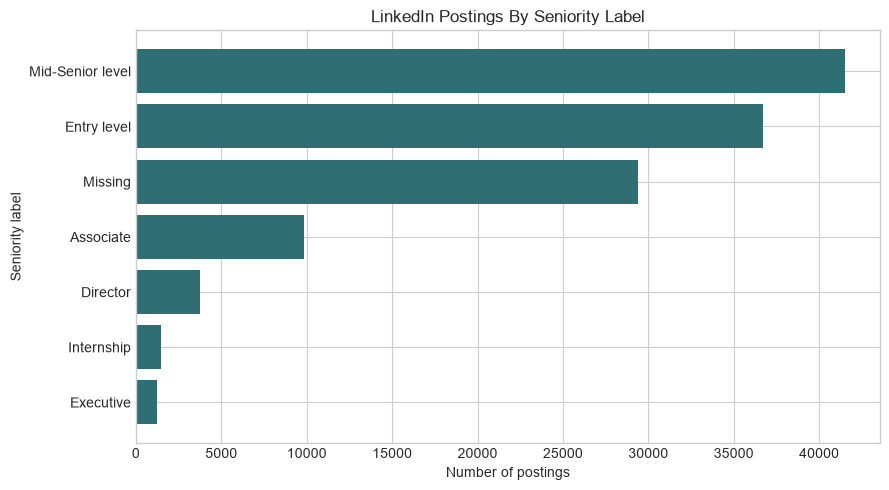

In [12]:
# Explore the seniority label distribution.

seniority_counts = (
    jobs["formatted_experience_level"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("seniority_label")
    .reset_index(name="postings")
)
seniority_counts["share"] = seniority_counts["postings"] / seniority_counts["postings"].sum()

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = seniority_counts.copy()
ax.barh(plot_data["seniority_label"], plot_data["postings"], color="#2f6f73")
ax.set_title("LinkedIn Postings By Seniority Label")
ax.set_xlabel("Number of postings")
ax.set_ylabel("Seniority label")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


The dataset is not evenly distributed. `Mid-Senior level` and `Entry level` are the two largest classes, while `Executive`, `Internship`, and `Director` are much smaller. There is also a large number of missing seniority labels.

This class balance affects model evaluation. Accuracy alone would be misleading because a model could do reasonably well by focusing on the largest classes. Therefore, we should evaluate macro F1, class-level precision/recall, and confusion matrices from model outputs rather than relying on accuracy alone.

In [13]:
# Look at a few Entry-level-labeled postings with multiple warning signals.
# warning signals are features created earlier that indicate the posting may not be truly entry-level.

entry_warning_examples = (
    jobs[
        (jobs["formatted_experience_level"] == "Entry level")
        & (jobs["rule_based_entry_warning_count"] >= 2)
    ]
    .sort_values("rule_based_entry_warning_count", ascending=False)
    [
        [
            "title",
            "company_name",
            "location",
            "max_years_mentioned",
            "mentions_5plus_years",
            "title_sounds_senior",
            "mentions_leadership_language",
            "rule_based_entry_warning_count",
        ]
    ]
    .head(10)
)

entry_warning_examples

,title,company_name,location,max_years_mentioned,mentions_5plus_years,title_sounds_senior,mentions_leadership_language,rule_based_entry_warning_count
31456,Sr. Security Technician,TEKsystems,"Grove City, OH",5.0,True,True,True,5
50586,"Marketing Manager, Product & New Business",Kohler Co.,"Bristol, PA",15.0,True,True,True,5
6748,Project Manager,Experis,"West Point, PA",70.0,True,True,True,5
28346,"Manager, Software Engineer",Capital One,"Richmond, VA",7.0,True,True,True,5
23771,"Director, Carrier & Connectivity Partnerships",Skydio,"San Mateo, CA",10.0,True,True,True,5
47422,"Project Manager, Regulatory (Hybrid)",Eversource Energy,"Westwood, MA",8.0,True,True,True,5
112802,Manager Central Sterile Processing,HCA Houston Healthcare,"Houston, TX",30.0,True,True,True,5
47320,Product Development Manager (Physical Product),Lovevery,"Boise, ID",5.0,True,True,True,5
116181,Principal Mechanical Engineer - Advanced Reactors,Westinghouse Electric Company,"Pittsburgh, PA",8.0,True,True,True,5
116159,Principal Process Safety Engineer,Westinghouse Electric Company,"Willowbrook, IL",30.0,True,True,True,5


This example relates to the core project questions. Several roles labeled `Entry level` have titles like manager, mention `5+` years, and carry multiple seniority warning signals.

This does not prove the label is wrong, but it shows the business problem exists in the data. It also helps us understand what the final mismatch score is trying to surface: not random low-quality postings, but postings whose language conflicts with an entry-level label.

In [14]:
# Compare warning signals by labeled seniority.

labeled_jobs = jobs[
    jobs["formatted_experience_level"].notna()
    & (jobs["description_word_count"] >= MIN_DESCRIPTION_WORDS)
].copy()

warning_by_seniority = (
    labeled_jobs.groupby("formatted_experience_level")
    .agg(
        postings=("job_id", "count"),
        pct_mentions_3plus_years=("mentions_3plus_years", "mean"),
        pct_mentions_5plus_years=("mentions_5plus_years", "mean"),
        pct_title_sounds_senior=("title_sounds_senior", "mean"),
        avg_warning_count=("rule_based_entry_warning_count", "mean"),
    )
    .reset_index()
    .sort_values("postings", ascending=False)
)

warning_by_seniority

,formatted_experience_level,postings,pct_mentions_3plus_years,pct_mentions_5plus_years,pct_title_sounds_senior,avg_warning_count
5,Mid-Senior level,41237,0.516963,0.413221,0.517302,2.477266
2,Entry level,36576,0.309329,0.226159,0.063976,1.399579
0,Associate,9814,0.387508,0.245568,0.229672,1.745364
1,Director,3741,0.641540,0.593692,0.898690,3.460037
4,Internship,1447,0.217001,0.191431,0.038701,1.406358
3,Executive,1216,0.571546,0.521382,0.837171,3.253289


We can see that the warning signals generally increase with seniority. For example, `Director` and `Executive` roles have much higher average warning counts than `Entry level`, and senior-sounding titles are much more common in higher seniority classes. This supports the modeling plan: the warning signals are not arbitrary.

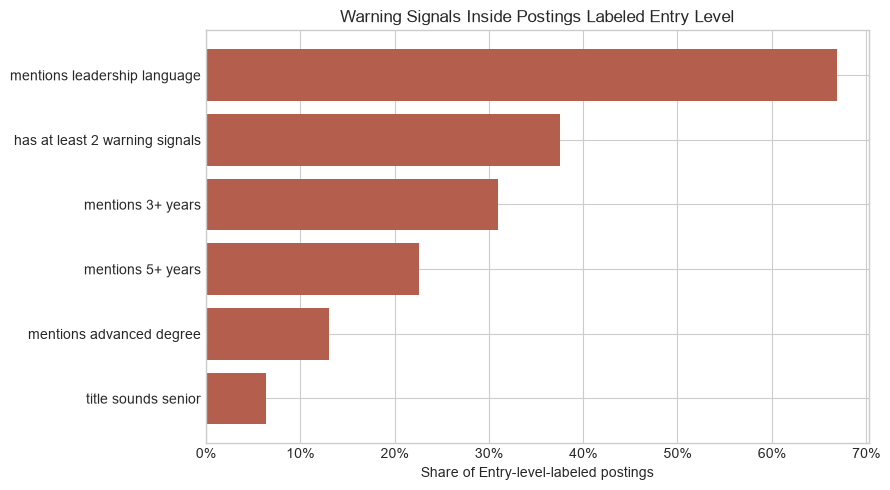

In [15]:
# Focus on postings labeled Entry level.
# These are the postings where a mismatch matters most to the target user.

entry_jobs = labeled_jobs[labeled_jobs["formatted_experience_level"] == "Entry level"].copy()

entry_warning_summary = pd.DataFrame(
    {
        "entry_level_signal": [
            "mentions 3+ years",
            "mentions 5+ years",
            "mentions advanced degree",
            "mentions leadership language",
            "title sounds senior",
            "has at least 2 warning signals",
        ],
        "postings": [
            entry_jobs["mentions_3plus_years"].sum(),
            entry_jobs["mentions_5plus_years"].sum(),
            entry_jobs["mentions_advanced_degree"].sum(),
            entry_jobs["mentions_leadership_language"].sum(),
            entry_jobs["title_sounds_senior"].sum(),
            (entry_jobs["rule_based_entry_warning_count"] >= 2).sum(),
        ],
    }
)
entry_warning_summary["share_of_entry_level_postings"] = entry_warning_summary["postings"] / len(entry_jobs)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = entry_warning_summary.sort_values("share_of_entry_level_postings")
ax.barh(plot_data["entry_level_signal"], plot_data["share_of_entry_level_postings"], color="#b45f4d")
ax.set_title("Warning Signals Inside Postings Labeled Entry Level")
ax.set_xlabel("Share of Entry-level-labeled postings")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()


Among postings labeled as `Entry level`, about 30.9% mention 3+ years, 22.6% mention 5+ years, 13.1% mention advanced-degree language, 67.5% mention leadership language, 6.0% have senior-sounding titles, and 37.4% have at least two warning signals.

This suggests there is a real screening problem for job seekers: many entry-level-labeled postings contain language that may feel more demanding than the label suggests.

## 3. Modeling

**TF-IDF: Term Frequency - Inverse Document Frequency** <br>
TF-IDF is a text-vectorization method that converts text into numeric features so machine learning models can use it. It gives higher weight to words that are frequent in one document and not too common across every document. In the context of this project, it turns words and phrases into numeric features by giving more weight to terms that are important in one posting but not common across all postings.

We will compare three models on the same train/test split:

1. **Baseline:** `TF-IDF + LogisticRegression` - strong, simple, and probability-friendly model.
2. **Test model 1:** `TF-IDF + Calibrated LinearSVC` - often excellent for sparse text / calibration gives probability-like scores.
3. **Test model 2:** a basic `TensorFlow` text-plus-tabular model to test if a neural model could add value beyond classical NLP.

In [19]:
# Prepare a modeling dataset.
# We do not use formatted_experience_level as an input because it is the label we are trying to predict.

modeling_data = labeled_jobs.copy()

# Sort before sampling so the same random seed produces the same modeling sample across reruns.
modeling_data = modeling_data.sort_values("job_id").reset_index(drop=True)

# Cap the number of rows for fast portfolio training.
# A simple random sample keeps the notebook fast while preserving every column needed downstream.
if len(modeling_data) > MAX_MODEL_ROWS:
    modeling_data = modeling_data.sample(n=MAX_MODEL_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)

CATEGORICAL_FEATURES = ["formatted_work_type", "remote_status"]

NUMERIC_FEATURES = [
    "salary_present",
    "skill_count",
    "industry_count",
    "benefit_count",
    "description_word_count",
    "mentions_3plus_years",
    "mentions_5plus_years",
    "mentions_advanced_degree",
    "mentions_leadership_language",
    "title_sounds_senior",
    "title_sounds_junior",
]

modeling_features = [
    "title_clean",
    "description_clean",
    "posting_text",
    *CATEGORICAL_FEATURES,
    *NUMERIC_FEATURES,
]

X = modeling_data[modeling_features].copy()
y = modeling_data["formatted_experience_level"].copy()

print(f"Modeling rows: {len(modeling_data):,}")
print("Modeling classes:")
print(y.value_counts())

Modeling rows: 12,000
Modeling classes:
formatted_experience_level
Mid-Senior level    5200
Entry level         4649
Associate           1317
Director             498
Internship           169
Executive            167
Name: count, dtype: int64


In [20]:
# Split the data before modeling.
# Stratification keeps the seniority mix similar across train and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Train rows: 9,600
Test rows: 2,400


In [21]:
# Track model results in one place for easy comparison.

model_results = []
model_registry = {}
prediction_registry = {}

def record_model_result(model_name, y_true, y_pred):
    """Print a classification report and store portfolio-friendly comparison metrics."""
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    print(classification_report(y_true, y_pred, zero_division=0))

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "entry_level_precision": report.get("Entry level", {}).get("precision", np.nan),
        "entry_level_recall": report.get("Entry level", {}).get("recall", np.nan),
        "entry_level_f1": report.get("Entry level", {}).get("f1-score", np.nan),
    }
    model_results.append(result)
    return pd.Series(result)

### (a) Baseline: TF-IDF + Logistic Regression

Logistic Regression with TF-IDF is a strong text-classification model, and it gives class probabilities naturally. This makes it a strong baseline model because we need probability estimates to create a mismatch score.

In [22]:
# Build the baseline with its own classical NLP preprocessing pipeline.
# Text becomes TF-IDF features, categorical context becomes one-hot features, and numeric warning signals are scaled.

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                max_features=12000,
                ngram_range=(1, 2),
                min_df=3,
                stop_words="english",
            ),
            "posting_text",
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES,
        ),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
                    ("scaler", StandardScaler(with_mean=False)),
                ]
            ),
            NUMERIC_FEATURES,
        ),
    ],
    remainder="drop",
)

logistic_baseline = Pipeline(
    steps=[
        ("features", logistic_preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1500,
                solver="saga",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_baseline.fit(X_train, y_train)
logistic_predictions = logistic_baseline.predict(X_test)

logistic_result = record_model_result(
    "Baseline: TF-IDF + LogisticRegression",
    y_test,
    logistic_predictions
)
model_registry[logistic_result["model"]] = logistic_baseline
prediction_registry[logistic_result["model"]] = logistic_predictions
logistic_result.to_frame("value")

                  precision    recall  f1-score   support

       Associate       0.39      0.52      0.45       263
        Director       0.58      0.52      0.55       100
     Entry level       0.77      0.78      0.77       930
       Executive       0.23      0.52      0.32        33
      Internship       0.43      0.85      0.57        34
Mid-Senior level       0.77      0.65      0.71      1040

        accuracy                           0.68      2400
       macro avg       0.53      0.64      0.56      2400
    weighted avg       0.71      0.68      0.69      2400



,value
model,Baseline: TF-IDF + LogisticRegression
accuracy,0.6825
macro_f1,0.562133
weighted_f1,0.690866
entry_level_precision,0.769394
entry_level_recall,0.778495
entry_level_f1,0.773918


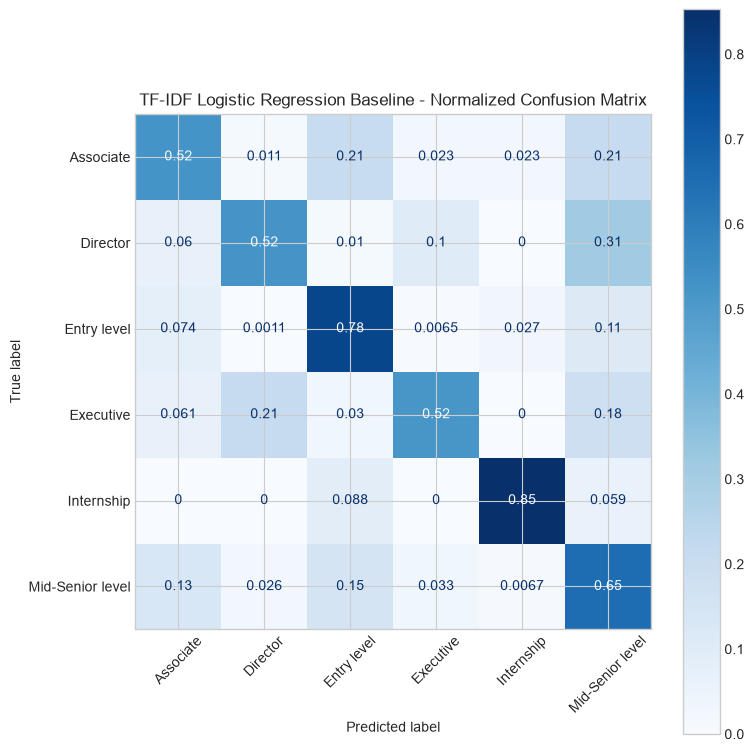

In [23]:
# Plot the baseline confusion matrix.
# The matrix shows which seniority labels the model tends to confuse with each other.

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    normalize="true",
    xticks_rotation=45,
    cmap="Blues",
    ax=ax,
)
ax.set_title("TF-IDF Logistic Regression Baseline - Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

The normalized confusion matrix shows that the Logistic Regression baseline performs best on the clearest seniority groups, especially `Entry level`, `Internship`, and `Mid-Senior level`. It correctly identifies about 78% of true Entry-level postings, 85% of Internship postings, and 65% of Mid-Senior postings.

The main confusion is between neighboring or overlapping seniority categories. For example, some `Associate` postings are predicted as `Entry level` or `Mid-Senior level`, and some `Director` / `Executive` postings are predicted as `Mid-Senior level`. This makes sense because job titles and descriptions often use similar leadership or responsibility language across these seniority levels.

Regarding the research question, the model correctly classifies most Entry-level postings, but about 11% are predicted as `Mid-Senior level` and about 7% as `Associate`, which supports the idea that some entry-level-labeled postings may contain more advanced language.

### (b) Test Model 1: Calibrated TF-IDF LinearSVC

LinearSVC is a Support Vector Classifier that uses a linear decision boundary, making it more scalable than a standard kernel-based SVC on high-dimensional text features like TF-IDF. LinearSVC is a strong challenger here because linear margin-based models often perform well on sparse TF-IDF features, and it gives us a strong classical benchmark to compare against baseline model. The catch is that raw LinearSVC scores are margins, not probabilities. Since we need a mismatch score for this project, we wrap it in **CalibratedClassifierCV**, which maps the model’s margin scores to probability-like estimates using only the training data.

In [24]:
# Train a calibrated LinearSVC challenger.
# Calibration is performed inside cross-validation on the training set, then we evaluate once on the untouched test set.

calibrated_svc_preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                max_features=12000,
                ngram_range=(1, 2),
                min_df=3,
                stop_words="english",
            ),
            "posting_text",
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES,
        ),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
                    ("scaler", StandardScaler(with_mean=False)),
                ]
            ),
            NUMERIC_FEATURES,
        ),
    ],
    remainder="drop",
)

calibrated_svc_model = Pipeline(
    steps=[
        ("features", calibrated_svc_preprocessor),
        (
            "classifier",
            CalibratedClassifierCV(
                estimator=LinearSVC(
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    max_iter=4000,
                ),
                method="sigmoid",
                cv=3,
            ),
        ),
    ]
)

calibrated_svc_model.fit(X_train, y_train)
calibrated_svc_predictions = calibrated_svc_model.predict(X_test)

calibrated_svc_result = record_model_result(
    "Test 1: TF-IDF + Calibrated LinearSVC",
    y_test,
    calibrated_svc_predictions
)
model_registry[calibrated_svc_result["model"]] = calibrated_svc_model
prediction_registry[calibrated_svc_result["model"]] = calibrated_svc_predictions
calibrated_svc_result.to_frame("value")

                  precision    recall  f1-score   support

       Associate       0.64      0.22      0.33       263
        Director       0.61      0.34      0.44       100
     Entry level       0.76      0.84      0.80       930
       Executive       0.75      0.27      0.40        33
      Internship       0.89      0.74      0.81        34
Mid-Senior level       0.72      0.82      0.77      1040

        accuracy                           0.73      2400
       macro avg       0.73      0.54      0.59      2400
    weighted avg       0.72      0.73      0.71      2400



,value
model,Test 1: TF-IDF + Calibrated LinearSVC
accuracy,0.7325
macro_f1,0.588834
weighted_f1,0.711542
entry_level_precision,0.757546
entry_level_recall,0.836559
entry_level_f1,0.795095


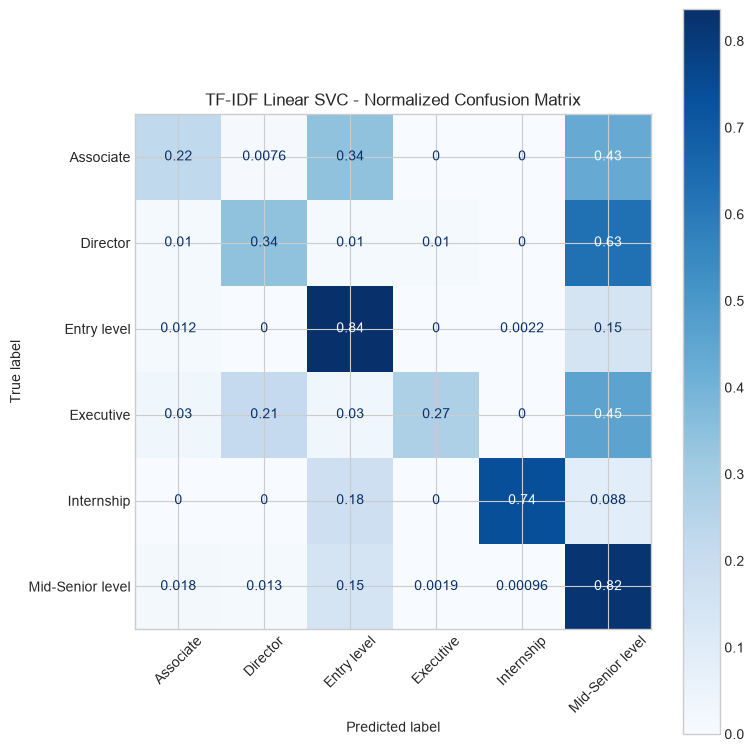

In [ ]:
# Plot the calibrated LinearSVC confusion matrix.
# The matrix shows which seniority labels the model tends to confuse with each other.

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    calibrated_svc_predictions,
    normalize="true",
    xticks_rotation=45,
    cmap="Blues",
    ax=ax,
)
ax.set_title("TF-IDF Linear SVC - Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

The calibrated LinearSVC model performs strongest on the two largest and most important classes for this project: `Entry level` and `Mid-Senior level`. It correctly identifies about 84% of true Entry-level postings and about 82% of true Mid-Senior postings.

The model still struggles with smaller or overlapping seniority classes. For example, many true `Associate`, `Director`, and `Executive` postings are predicted as `Mid-Senior level`, suggesting that their descriptions often share similar responsibility, leadership, or experience language with mid-senior roles.

Regarding the research question, the most important row is `Entry level`. About 15% of true Entry-level postings are predicted as `Mid-Senior level`, which is exactly the type of mismatch signal this project is designed to surface for review.

Compared with the Logistic Regression baseline, the calibrated LinearSVC is better at recognizing `Entry level` and `Mid-Senior level` postings. However, it appears more likely to collapse some smaller seniority classes into `Mid-Senior level`, so the improvement comes with a tradeoff in minority-class interpretability.

### (c) Test Model 2: Basic TensorFlow Text + Tabular Model

The TensorFlow model learns word embeddings from scratch and combines text features with simple structured context. We wanted to include it to test whether a basic neural model adds value beyond classical NLP methods on this dataset.

In [26]:
# Import TensorFlow in its own cell so environment issues are easy to diagnose.
# If this cell fails, install the project dependencies before rerunning.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(RANDOM_STATE)
print(tf.__version__)

2026-07-01 20:51:19.933907: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.16.2


In [27]:
# Encode text labels as integer class IDs for Keras.
# We keep class_names visible because they will be needed for evaluation and mismatch scoring.

label_encoder = LabelEncoder()
y_train_ids = label_encoder.fit_transform(y_train)
y_test_ids = label_encoder.transform(y_test)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(class_names)

['Associate', 'Director', 'Entry level', 'Executive', 'Internship', 'Mid-Senior level']


In [ ]:
# Prepare a text-plus-tabular TensorFlow dataset.
# The structured columns are intentionally simple and job-seeker interpretable.

X_train_tf = X_train.copy()
X_test_tf = X_test.copy()

for column in CATEGORICAL_FEATURES:
    X_train_tf[column] = X_train_tf[column].fillna("missing").astype(str)
    X_test_tf[column] = X_test_tf[column].fillna("missing").astype(str)

for column in NUMERIC_FEATURES:
    X_train_tf[column] = X_train_tf[column].fillna(0).astype("float32")
    X_test_tf[column] = X_test_tf[column].fillna(0).astype("float32")

BATCH_SIZE = 512
AUTOTUNE = tf.data.AUTOTUNE

# Convert a pandas feature frame into the dictionary expected by the Keras model.
train_tf_inputs = {
    "posting_text": X_train_tf["posting_text"].fillna("").astype(str).values,
    "numeric_features": X_train_tf[NUMERIC_FEATURES].astype("float32").values,
}
test_tf_inputs = {
    "posting_text": X_test_tf["posting_text"].fillna("").astype(str).values,
    "numeric_features": X_test_tf[NUMERIC_FEATURES].astype("float32").values,
}

for column in CATEGORICAL_FEATURES:
    train_tf_inputs[column] = X_train_tf[column].fillna("missing").astype(str).values
    test_tf_inputs[column] = X_test_tf[column].fillna("missing").astype(str).values

# Build a batched tf.data dataset from pandas features and optional labels.
train_tf_ds = tf.data.Dataset.from_tensor_slices((train_tf_inputs, y_train_ids))
train_tf_ds = train_tf_ds.shuffle(20000, seed=RANDOM_STATE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_tf_ds = tf.data.Dataset.from_tensor_slices((test_tf_inputs, y_test_ids))
test_tf_ds = test_tf_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

text_vectorizer = layers.TextVectorization(
    max_tokens=15000,
    output_mode="int",
    output_sequence_length=180,
    standardize="lower_and_strip_punctuation",
)
text_vectorizer.adapt(X_train_tf["posting_text"].fillna("").astype(str).values)

print("Text vectorizer vocabulary size:", len(text_vectorizer.get_vocabulary()))

Text vectorizer vocabulary size: 15000


In [29]:
# Build a basic TensorFlow model with text, categorical, and numeric branches.
# This is intentionally close to an initial neural setup, not a heavily tuned architecture.

tf_inputs = {}
encoded_parts = []

# Text branch
tf_inputs["posting_text"] = keras.Input(shape=(1,), dtype=tf.string, name="posting_text")
text_branch = text_vectorizer(tf_inputs["posting_text"])
text_branch = layers.Embedding(input_dim=len(text_vectorizer.get_vocabulary()), output_dim=64)(text_branch)
text_branch = layers.GlobalAveragePooling1D()(text_branch)
encoded_parts.append(text_branch)

# Numeric branch
tf_inputs["numeric_features"] = keras.Input(shape=(len(NUMERIC_FEATURES),), dtype=tf.float32, name="numeric_features")
normalizer = layers.Normalization()
normalizer.adapt(X_train_tf[NUMERIC_FEATURES].astype("float32").values)
encoded_parts.append(normalizer(tf_inputs["numeric_features"]))

# Categorical branches
for column in CATEGORICAL_FEATURES:
    tf_inputs[column] = keras.Input(shape=(1,), dtype=tf.string, name=column)
    lookup = layers.StringLookup(output_mode="int", num_oov_indices=1, name=f"{column}_lookup")
    lookup.adapt(X_train_tf[column].astype(str).values)
    vocab_size = lookup.vocabulary_size()
    embedding_dim = min(8, max(2, int(np.sqrt(vocab_size))))
    encoded_category = lookup(tf_inputs[column])
    encoded_category = layers.Embedding(vocab_size, embedding_dim, name=f"{column}_embedding")(encoded_category)
    encoded_category = layers.Flatten()(encoded_category)
    encoded_parts.append(encoded_category)

combined = layers.Concatenate()(encoded_parts)
combined = layers.Dense(128, activation="relu")(combined)
combined = layers.Dropout(0.30)(combined)
combined = layers.Dense(64, activation="relu")(combined)
combined = layers.Dropout(0.20)(combined)
tf_output = layers.Dense(num_classes, activation="softmax", name="seniority_prediction")(combined)

tensorflow_model = keras.Model(inputs=tf_inputs, outputs=tf_output)
tensorflow_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"TensorFlow model parameters: {tensorflow_model.count_params():,}")

tensorflow_history = tensorflow_model.fit(
    train_tf_ds,
    validation_data=test_tf_ds,
    epochs=2,
    verbose=0,
)

# Show compact training diagnostics instead of a long epoch-by-epoch console log.
tensorflow_history_df = pd.DataFrame(tensorflow_history.history)
tensorflow_history_df.index = tensorflow_history_df.index + 1
tensorflow_history_df.index.name = "epoch"
tensorflow_history_df

TensorFlow model parameters: 978,931


,accuracy,loss,val_accuracy,val_loss
epoch,,,,
1,0.447083,1.538383,0.58000,1.224824
2,0.569375,1.170545,0.59625,1.040823


In [30]:
# Evaluate the TensorFlow model on the same held-out test set.
# This keeps the comparison fair: same rows, same labels, same metrics.

tensorflow_probabilities = tensorflow_model.predict(test_tf_ds, verbose=0)
tensorflow_predictions = label_encoder.inverse_transform(tensorflow_probabilities.argmax(axis=1))

tensorflow_result = record_model_result(
    "Test 2: Basic TensorFlow text + tabular",
    y_test,
    tensorflow_predictions
)
model_registry[tensorflow_result["model"]] = tensorflow_model
prediction_registry[tensorflow_result["model"]] = tensorflow_predictions
tensorflow_result.to_frame("value")

                  precision    recall  f1-score   support

       Associate       0.17      0.00      0.01       263
        Director       0.00      0.00      0.00       100
     Entry level       0.58      0.77      0.66       930
       Executive       0.00      0.00      0.00        33
      Internship       0.00      0.00      0.00        34
Mid-Senior level       0.61      0.69      0.65      1040

        accuracy                           0.60      2400
       macro avg       0.23      0.24      0.22      2400
    weighted avg       0.51      0.60      0.54      2400



,value
model,Test 2: Basic TensorFlow text + tabular
accuracy,0.59625
macro_f1,0.219721
weighted_f1,0.538526
entry_level_precision,0.582516
entry_level_recall,0.766667
entry_level_f1,0.662024


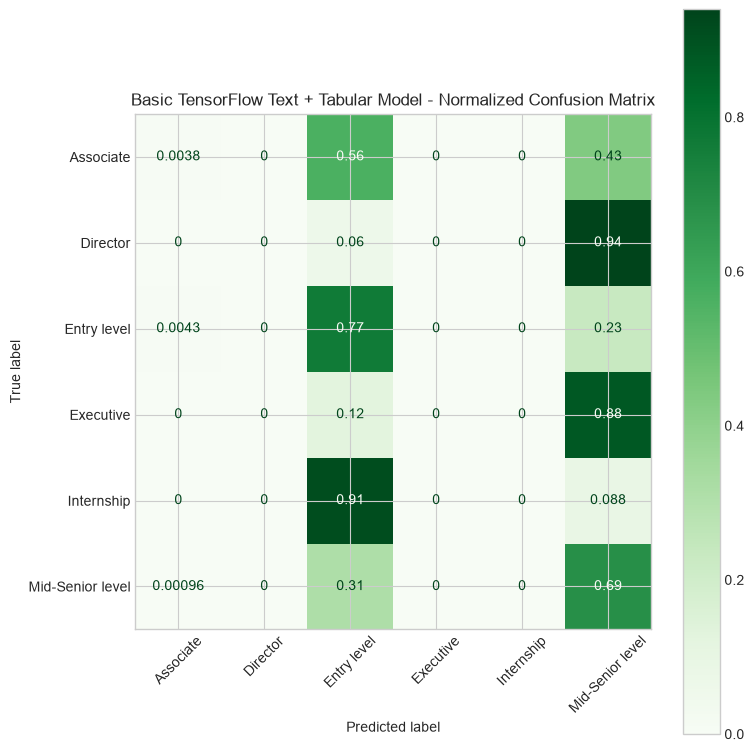

In [31]:
# Plot the TensorFlow confusion matrix.
# For this project, confusion between Entry level and higher seniority classes is the most important pattern.

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tensorflow_predictions,
    normalize="true",
    xticks_rotation=45,
    cmap="Greens",
    ax=ax,
)
ax.set_title("Basic TensorFlow Text + Tabular Model - Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

The TensorFlow confusion matrix shows that the basic neural model is mostly separating postings into only two classes: `Entry level` and `Mid-Senior level`. It correctly identifies about 77% of true Entry-level postings and 69% of true Mid-Senior postings, but it rarely predicts the smaller classes such as `Associate`, `Director`, `Executive`, or `Internship`.

This pattern suggests that the TensorFlow model is under-learning the full seniority structure. Instead of distinguishing all seniority levels, it collapses many postings into the two largest classes, which is why its macro F1 is much weaker than its Entry-level recall might suggest.

Regarding the research question, the TensorFlow model still captures some Entry-level versus Mid-Senior contrast, but it is less reliable as a general seniority classifier. It may be useful as a proof of concept, but it does not yet justify replacing the stronger classical text models.

Compared with Logistic Regression and calibrated LinearSVC, the TensorFlow model has a much weaker confusion matrix because it fails to meaningfully identify most minority classes. The classical TF-IDF models spread predictions across more seniority labels and provide a more balanced classification result.

## 4. Evaluation: Model Comparison And Conclusion

Now we compare the three models. A model can be valuable even if it does not win, but only if we can explain what it taught us and what would be needed to improve it.

In [32]:
# Compare all model attempts.
# Weighted F1 reflects overall performance; macro F1 checks minority-class behavior; Entry-level F1 keeps the job-seeker goal visible.

model_results_df = pd.DataFrame(model_results).drop_duplicates("model", keep="last")
model_results_df = model_results_df.sort_values(
    ["entry_level_f1", "weighted_f1", "macro_f1"],
    ascending=False,
).reset_index(drop=True)
model_results_df

,model,accuracy,macro_f1,weighted_f1,entry_level_precision,entry_level_recall,entry_level_f1
0,Test 1: TF-IDF + Calibrated LinearSVC,0.73250,0.588834,0.711542,0.757546,0.836559,0.795095
1,Baseline: TF-IDF + LogisticRegression,0.68250,0.562133,0.690866,0.769394,0.778495,0.773918
2,Test 2: Basic TensorFlow text + tabular,0.59625,0.219721,0.538526,0.582516,0.766667,0.662024


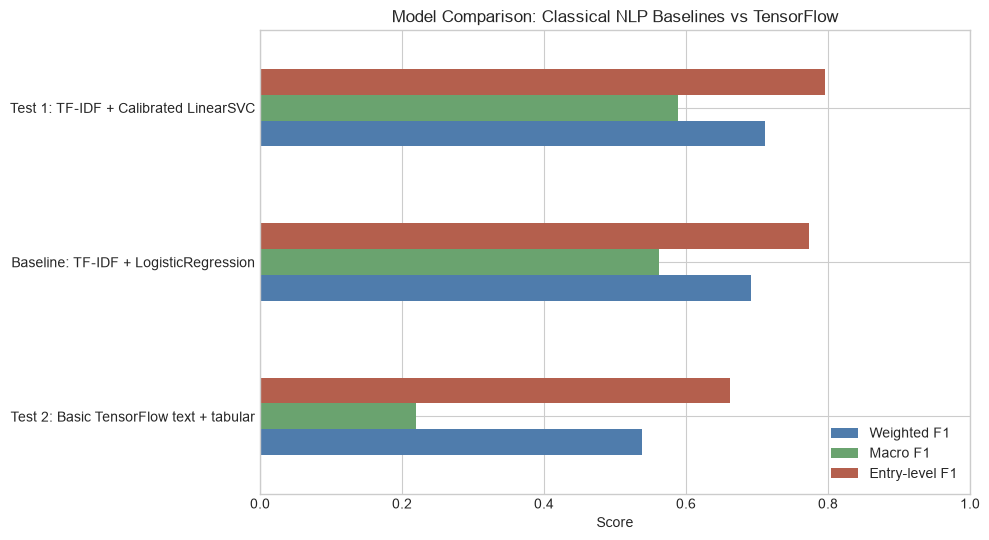

In [33]:
# Visualize the comparison so the modeling conclusion is easy to read.
# The chart keeps both the general model score and the Entry-level use case in view.

comparison_plot = model_results_df.set_index("model")[["weighted_f1", "macro_f1", "entry_level_f1"]].sort_values("entry_level_f1")

fig, ax = plt.subplots(figsize=(10, 5.5))
comparison_plot.plot(kind="barh", ax=ax, color=["#4f7cac", "#6aa36f", "#b45f4d"])
ax.set_title("Model Comparison: Classical NLP Baselines vs TensorFlow")
ax.set_xlabel("Score")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.legend(["Weighted F1", "Macro F1", "Entry-level F1"], loc="lower right")
plt.tight_layout()
plt.show()

The chart shows that the **Calibrated LinearSVC model performs best overall**, with the highest Entry-level F1, weighted F1, and macro F1. That makes it the strongest candidate for the final model because it handles the main job-seeker objective while also doing better across the broader seniority classes.

The **Logistic Regression baseline is very competitive**, especially on Entry-level F1. This tells us that the TF-IDF text features are already capturing many useful seniority signals, such as “intern,” “new grad,” “senior,” “lead,” or “manager.”

The **basic TensorFlow model performs weakest**, especially on macro F1. This suggests it struggles more with the smaller or harder-to-separate classes, even though it still captures some Entry-level patterns. For this dataset, the simpler TF-IDF linear models are more reliable than the basic neural network setup.

### Conclusion

After reviewing the metric table and the confusion matrices, the calibrated LinearSVC is the strongest model for this project. It has the highest Entry-level F1 score (`0.795`) and the highest weighted F1 score (`0.712`), which means it is best at the job-seeker goal while also performing best across the full seniority-label set.

The calibrated LinearSVC performs well because margin-based linear models are often effective with sparse TF-IDF text features. The calibration step also makes its output easier to use as a probability-like mismatch score. Its main weakness is that macro F1 (`0.589`) is lower than weighted F1, which suggests the model still struggles more with smaller or less clearly separated classes such as Associate, Director, and Executive.

The Logistic Regression baseline is still a strong and useful benchmark. Its Entry-level F1 score (`0.774`) is close to LinearSVC, which tells us that TF-IDF is already a good fit for this problem because seniority is often signaled through specific words and phrases. However, it trails LinearSVC on weighted F1, so it is not the strongest final model when overall classification quality matters.

The basic TensorFlow model underperforms both classical models. Its Entry-level recall is useful, but its Entry-level precision (`0.583`) and macro F1 (`0.219`) are much weaker. The confusion matrix shows that the model mostly predicts Entry level or Mid-Senior level instead of learning the full seniority structure, which suggests the basic neural model is under-learning from this dataset. To make TensorFlow more competitive, the next version would likely need pretrained language embeddings, stronger class-imbalance handling, longer training with early stopping, and possibly separate model branches for job title and job description text.

In [35]:
# Choose the final scoring model from evidence.
# Entry-level F1 is the main selection metric because the product is built around Entry-level mismatch detection.

selected_model_row = model_results_df.sort_values(
    ["entry_level_f1", "weighted_f1", "macro_f1"],
    ascending=False,
).iloc[0]
selected_model_name = selected_model_row["model"]
selected_model = model_registry[selected_model_name]
selected_predictions = prediction_registry[selected_model_name]

print(f"Selected scoring model: {selected_model_name}")
print(f"Entry-level F1: {selected_model_row['entry_level_f1']:.3f}")
print(f"Weighted F1: {selected_model_row['weighted_f1']:.3f}")

Selected scoring model: Test 1: TF-IDF + Calibrated LinearSVC
Entry-level F1: 0.795
Weighted F1: 0.712


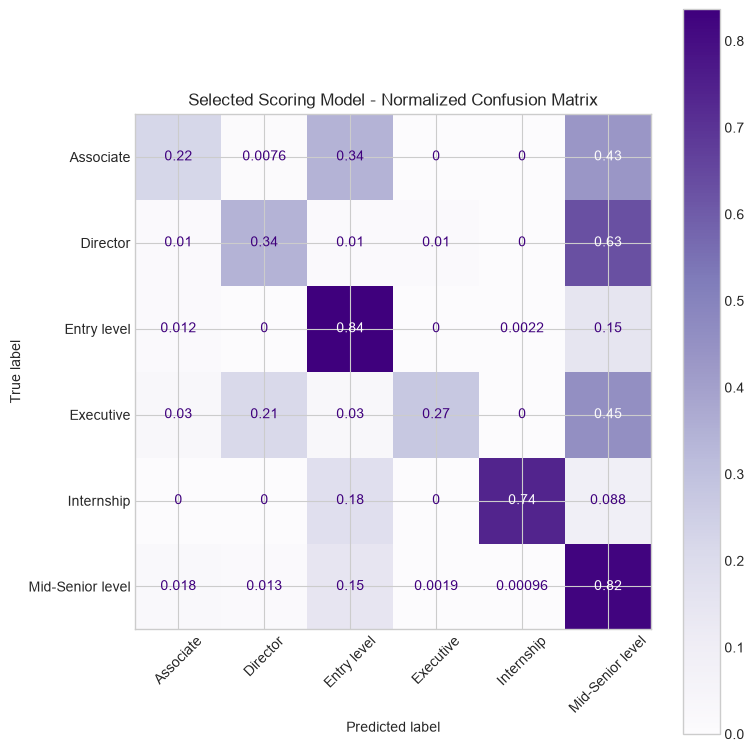

In [36]:
# Plot the selected model confusion matrix.
# This is the most important confusion matrix because it describes the model used for mismatch scoring.

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    selected_predictions,
    normalize="true",
    xticks_rotation=45,
    cmap="Purples",
    ax=ax,
)
ax.set_title("Selected Scoring Model - Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Save the selected model for deployment.

model_path = MODELS_DIR / "final_model.pkl"
with model_path.open("wb") as file:
    pickle.dump(selected_model, file)

## 5. Model Deployment with Dashboard

To make the model useful beyond the notebook, we created a Streamlit dashboard that turns the seniority classifier into a practical job-search prioritization tool. The app allows job seekers to filter entry-level-labeled postings by title keyword, work type, remote status, location, industry, skill, salary availability, and minimum true entry-level score.

For each matching posting, the dashboard shows the model’s true entry-level score, posting freshness, industry, salary visibility, and a direct posting link. Instead of asking users to manually read through hundreds of postings, the dashboard ranks jobs by how strongly they appear to match realistic entry-level expectations. The dashboard also includes a CSV export option so users can save their filtered job list and continue tracking applications according to their personal job-search workflow.

This deployment step connects the modeling work back to the original business problem: helping recent graduates and career changers spend their application time on postings that are more likely to fit their experience level.

In [43]:
# Export a compact, dashboard-ready dataset for Streamlit app.

APP_DATA_DIR = PROJECT_ROOT / "data" / "streamlit"
APP_DATA_DIR.mkdir(parents=True, exist_ok=True)
APP_DATA_PATH = APP_DATA_DIR / "app_dataset.csv"

def build_dashboard_warning_reasons(row):
    """Create concise reasons that explain visible seniority warning signals."""
    reasons = []
    if row.get("mentions_5plus_years"):
        reasons.append("mentions 5+ years")
    elif row.get("mentions_3plus_years"):
        reasons.append("mentions 3+ years")
    if row.get("title_sounds_senior"):
        reasons.append("senior title language")
    if row.get("mentions_advanced_degree"):
        reasons.append("advanced degree language")
    if row.get("mentions_leadership_language"):
        reasons.append("leadership/ownership language")
    if not reasons:
        reasons.append("few obvious seniority warning terms")
    return "; ".join(reasons)

dashboard_df = jobs[jobs["formatted_experience_level"].eq("Entry level")].copy()

dashboard_probabilities = selected_model.predict_proba(dashboard_df[modeling_features])
dashboard_probability_frame = pd.DataFrame(
    dashboard_probabilities,
    columns=selected_model.classes_,
    index=dashboard_df.index,
)

dashboard_df["predicted_seniority"] = dashboard_probability_frame.idxmax(axis=1)
dashboard_df["true_entry_level_score"] = dashboard_probability_frame["Entry level"]
dashboard_df["entry_level_mismatch_score"] = 1 - dashboard_df["true_entry_level_score"]
dashboard_df["warning_reasons"] = dashboard_df.apply(build_dashboard_warning_reasons, axis=1)
dashboard_df["salary_display"] = np.where(
    dashboard_df["normalized_salary"].notna(),
    dashboard_df["normalized_salary"].round(0).map(lambda value: f"${value:,.0f}"),
    "Not Listed",
)
dashboard_df["listed_date"] = pd.to_datetime(
    dashboard_df["listed_time"],
    unit="ms",
    errors="coerce",
).dt.date

dashboard_columns = [
    "job_id",
    "title_clean",
    "title",
    "company_name",
    "location",
    "industry_text",
    "skill_text",
    "formatted_work_type",
    "remote_status",
    "listed_date",
    "true_entry_level_score",
    "predicted_seniority",
    "salary_display",
    "warning_reasons",
    "job_posting_url",
    "salary_present",
    "views",
]

streamlit_export = dashboard_df[dashboard_columns].copy()
streamlit_export.to_csv(APP_DATA_PATH, index=False)

file_size_mb = APP_DATA_PATH.stat().st_size / (1024 * 1024)
print(f"Rows exported: {len(streamlit_export):,}")
print(f"File size: {file_size_mb:.2f} MB")

Rows exported: 36,708
File size: 12.71 MB
